### Objective:
The dataset is designed for exploring factors influencing customer churn and retention. It is ideal for developing predictive models to identify at-risk customers and understand the dynamics of customer turnover. Key analyses can include identifying patterns in customer demographics, contract types, and service usage that contribute to churn.

This dataset provides a comprehensive view of customer behavior and churn in the telecom industry. It includes detailed information on customer demographics, service usage, and various indicators that are critical for analyzing customer retention and churn.

**Dataset:** https://www.kaggle.com/datasets/abdullah0a/telecom-customer-churn-insights-for-analysis

**Target Variable:** Churn

**Applications:**
Churn Prediction: Build models to predict customer churn based on their attributes and service details.
Customer Segmentation: Segment customers to understand different behavior patterns and tailor retention strategies.
Trend Analysis: Analyze trends in customer tenure, monthly charges, and contract types to gain insights into churn drivers.
Feature Engineering: Use the dataset to create features for more sophisticated churn prediction models.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_churn_data.csv")

In [3]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes


In [4]:
df.shape # (rows, columns)

(1000, 10)

In [5]:
# Let get the structural summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [6]:
# We have 3 integer columns, 5 objects, & 2 columns are float datatype

In [7]:
# Lets check null values
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [8]:
df.isna().sum().sum()

np.int64(297)

We gonna drop (dropna()) these 297 columns, becoz its totally unnecessary because we have values in the other ones and if we not going to include internet service in our modeling side we need to drop that 300.

In [9]:
# It consumes 30% of our dataset, so lets fill the NA vlues by something similar 
df["InternetService"].value_counts()

InternetService
Fiber Optic    395
DSL            308
Name: count, dtype: int64

In [10]:
df["InternetService"] = df["InternetService"].fillna("")
# fillna() replaces missing values.
# It replaces missing InternetService values with an empty string to avoid errors during preprocessing or modeling.
# Replace every NaN with: ""  (empty string)
# df["InternetService"] = ... --?> This updates the original dataframe. Without assignment, changes would not persist.

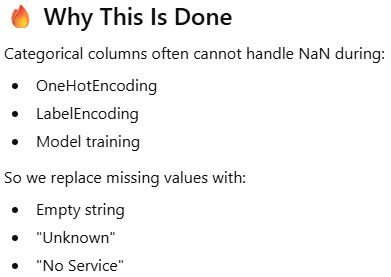

Using fillna(), we don't have any NA values in our dataset. So, no need to drop any kind of NA values

In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
# Lets check duplicates if we have
df.duplicated().sum()

np.int64(0)

In [13]:
# We don't have any updates, so we don't need to do somthing like dropping the duplicates

In [14]:
# Now, lets check the statistical summary of the data
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


### Interpreation
- Average customers age is 44.67, low as 12 yrs
- Tenure msx is 122 which indicates that we have customers who's having more than 10 years of relationship
- On monthly charges side, 74 is the mean
- Total charges we can see minimum as 0 and mean of 1404.364

In [15]:
# Lets see correlation between these values
numeric_columns_data = df.select_dtypes(include = ["number"])
# select_dtypes() is a pandas function used to select columns based on their data type
     # Eg: DataFrame.select_dtypes(include=..., exclude=...)
# include = ["number"] --> This select only columns that contain numeric data types.

In [16]:
numeric_columns_data.corr() # -1 is strong negative corr & +1 is strong positive corr

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [17]:
# Here we have highly correlated only with TotalCharges and Tenure
# Total charges = tenure * monthly charges

In [18]:
# Next lets do groupby and data visuzliation
# Let's start by seeing the value counts on the churn column
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [19]:
import matplotlib.pyplot as plt

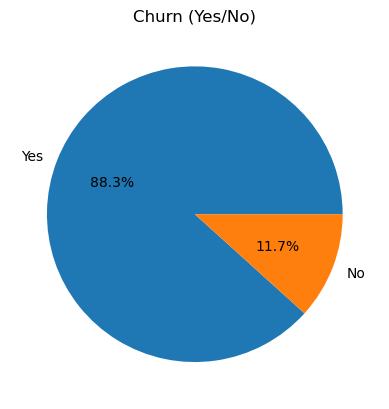

In [20]:
df["Churn"].value_counts().plot(kind = "pie", autopct="%1.1f%%")
# .value_counts() --> This counts how many times each value appears
# .plot(kind="pie") --> This converts the counts into a pie chart
# autopct="%1.1f%%" --> shows percentage
plt.title("Churn (Yes/No)")
plt.ylabel("")
plt.show()

We can see that the most of the cusomters in our dataset are CHURN here

In [21]:
# Next, lets do groupby based on churn
df.groupby("Churn")["MonthlyCharges"].mean()
# This splits the dataset into groups based on the Churn column.
           # Group 1 → All customers who churned
           # Group 2 → All customers who did not churn
# ["MonthlyCharges"] --> After grouping, you select only the MonthlyCharges column.
           # From each churn group, look only at MonthlyCharges
# .mean() --> this calculates the average MonthlyCharges for each group.

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

Now we can see that at higher monthly charges the churn probability is more

In [22]:
# We can also do multi-index groupby 
df.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

On the Churn side, Male has higher monthly charges than female

On the Non-Churn side, Female has higher monthly charges than male

In [23]:
# Now lets see it in tenure side
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

We can see higher chance of Churn at 17.4 months

Not Churn at 30.26 months

In [24]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

At the lower terms we can see that the monthly charge average decreases

In [25]:
df.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

Here we can see that at lower term contracts are with higher charges as it can be expected. So we can create a plot from this again since it returns a panda series 

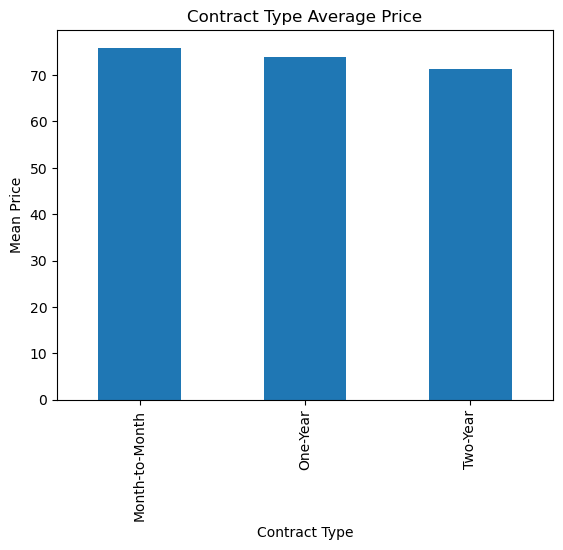

In [26]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind = "bar")
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")
plt.title("Contract Type Average Price")
plt.show()

In [27]:
df.head(2) # Lets call the df again

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


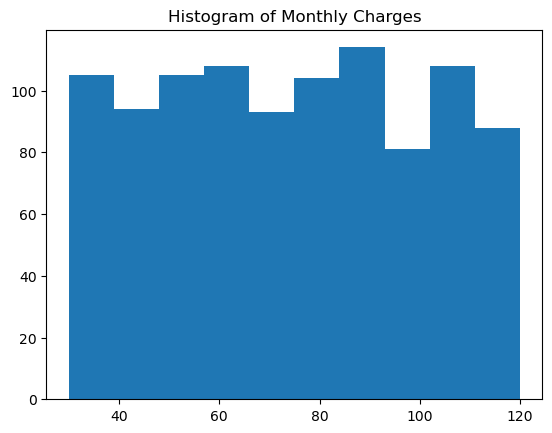

In [28]:
plt.hist(df["MonthlyCharges"])
plt.title("Histogram of Monthly Charges")
plt.show()

**Histogram helps you:**
- Detect skewness
- See outliers
- Decide if scaling is needed
- Decide if log transformation is required

**For example:**
- If heavily right-skewed → maybe apply log transformation
- If normally distributed → good for many models

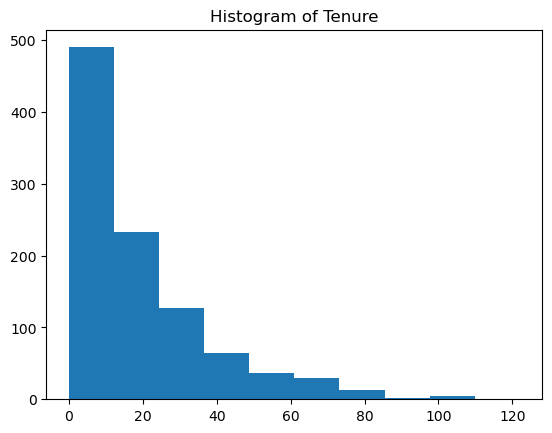

In [29]:
# Now lets do the histogram for tenure
plt.hist(df["Tenure"])
plt.title("Histogram of Tenure")
plt.show()

### FEATURE ENGINEERING

In [30]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [31]:
# Now lets separate the columns for model (feature and label)
df.head(1)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


In [32]:
y = df["Churn"] # Target/label
X = df[["Age", "Gender", "Tenure", "MonthlyCharges"]] # Feature

In [33]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [34]:
y

0      Yes
1      Yes
2      Yes
3      Yes
4      Yes
      ... 
995    Yes
996    Yes
997    Yes
998    Yes
999    Yes
Name: Churn, Length: 1000, dtype: object

In [35]:
# Next step: We need numeric values for modeling for both X and y
# Lets start convert from Gender using Binary Encoding
X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0) # This converts the Yes/No to 0s and 1s.
# Gender --> 1 Female 0 Male
# .apply(...) --> .apply() is used to apply a function to every value in the column
# lambda x: 1 if x == "Female" else 0 --> This is an anonymous function (lambda function).
          # If value is "Female" → return 1 & Otherwise → return 0

C:\Users\sugku\AppData\Local\Temp\ipykernel_25348\2983184827.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0) # This converts the Yes/No to 0s and 1s.


In [36]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [37]:
type(X["Gender"][0])
# type(...) --> This a built in fn. It tells the datatype
# X["Gender"][0] -->  # 👉 The value at index 0 👉 The first row of the Gender column

numpy.int64

In [38]:
# Gender columns contains integer datatype
# Lets do the same to Targe variable : Churn

In [39]:
y.head(2)

0    Yes
1    Yes
Name: Churn, dtype: object

In [40]:
type(y)

pandas.core.series.Series

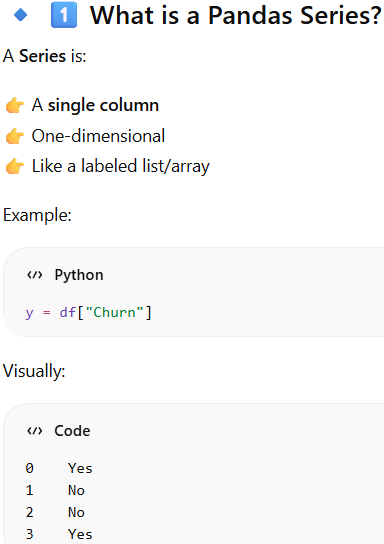

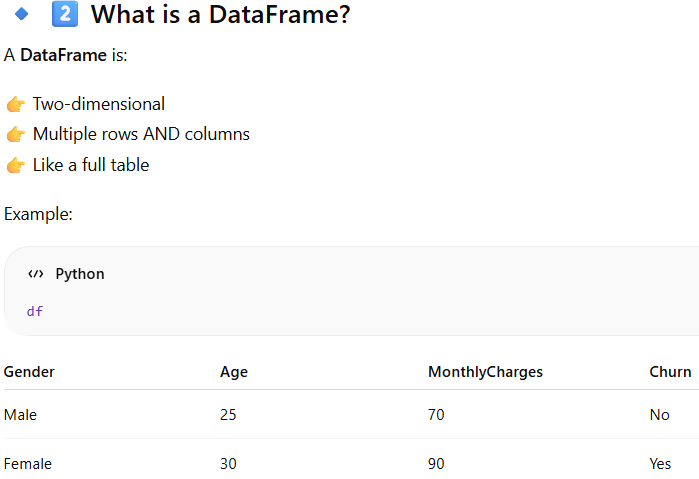

In [41]:
y = pd.DataFrame(y) # Convert it from series to dataframe
# Now it has 1 column, but it's 2D.

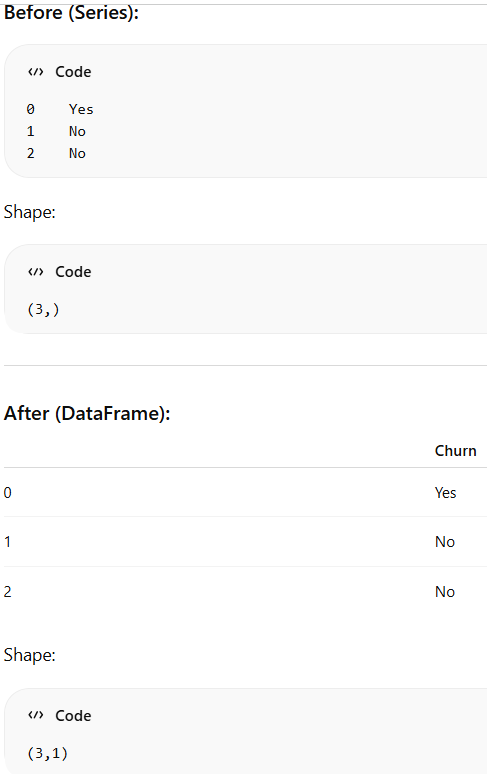

In [42]:
type(y)

pandas.core.frame.DataFrame

In [43]:
y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)
# Churn --> 1 Yes, 0 No

In [44]:
y

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


In [45]:
type(y["Churn"][0])

numpy.int64

In [46]:
# This contains integer value, perfect
# Now we have our y ready and X ready

In [47]:
# Next, will do train test split for model evaluation

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [49]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [50]:
# Lets scale the data
from sklearn.preprocessing import StandardScaler
# StandardScaler --> standardize (scale) numeric features. It transforms data so that Mean = 0 & Standard deviation = 1

In [51]:
scaler = StandardScaler()

In [52]:
# Lets scale the X_train dataset
X_train = scaler.fit_transform(X_train)
# fit() → learns mean & std from X_train
# transform() → applies scaling --> it scales X_train using those values
# fit_transform() → both together
# It standardizes numeric features by making their mean 0 and standard deviation 1.

In [53]:
import joblib
joblib.dump(scaler, "scaler.pkl") # scaler is exported to joblib as scaler.pkl
# To ensure data_leakage, imported the scaler file now

['scaler.pkl']

In [54]:
X_test = scaler.transform(X_test) # Lets scale the X_test 
# fit_transform() on training data
# transform() only on test data

In [55]:
X_train

array([[ 0.43496752,  0.92994724,  2.83325476, -0.22464292],
       [ 0.43496752,  0.92994724,  1.02413816, -0.50430188],
       [ 2.57854461,  0.92994724, -0.94944358,  1.38987505],
       ...,
       [-0.99408388,  0.92994724,  0.8048513 ,  1.01893045],
       [ 0.23081732,  0.92994724,  0.53074273, -0.20684996],
       [ 1.25156831, -1.07532982,  0.36627758, -0.64123033]],
      shape=(800, 4))

In [56]:
X_test

array([[-7.54079797e-02, -1.07532982e+00,  1.40789017e+00,
         8.34038361e-01],
       [ 1.14949321e+00, -1.07532982e+00, -6.75335002e-01,
        -3.43778414e-01],
       [-5.85783477e-01,  9.29947238e-01,  4.21099299e-01,
         1.51713341e+00],
       [-1.09615897e+00,  9.29947238e-01, -8.94621862e-01,
        -7.64613895e-03],
       [ 2.66671197e-02,  9.29947238e-01,  1.62717703e+00,
         4.14356521e-01],
       [ 9.45343015e-01,  9.29947238e-01,  1.02413816e+00,
         1.24172929e+00],
       [ 6.39117717e-01,  9.29947238e-01,  2.61396790e+00,
        -7.91696911e-01],
       [-5.85783477e-01, -1.07532982e+00,  2.56634154e-01,
         1.41660027e-01],
       [-5.85783477e-01, -1.07532982e+00, -7.30156717e-01,
        -1.70803449e+00],
       [ 1.65986871e+00,  9.29947238e-01, -7.22961367e-02,
        -1.15026379e+00],
       [-1.60653447e+00,  9.29947238e-01, -1.74744217e-02,
         6.46825448e-01],
       [ 1.35364341e+00, -1.07532982e+00, -7.84978432e-01,
      

In [57]:
# Now lets build the classification model
# For that lets define a funciton for getting the model performance (accuracy)
# This classify the values 0 to 1. The values closer to 1 is better
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test, predictions)))
    # y_test → actual values
    # predictions → model predicted values
    # .format(...) --> This inserts the accuracy value into the string.
# 👉 This function calculates and prints the accuracy of the model by comparing predicted values with actual test values

In [58]:
# Before starting the logisticregression, we going to import grid search and hyperparameter tunning
from sklearn.model_selection import GridSearchCV # This imports Grid Search with Cross Validation
# This imports Grid Search with Cross Validation.

In [59]:
from sklearn.linear_model import LogisticRegression
# This imports the Logistic Regression algorithm

In [60]:
log_model = LogisticRegression() # Initializes (creates) the model

In [61]:
log_model.fit(X_train, y_train) # This is where actual learning happens.
# What is happening internally?
      # X_train → Features (independent variables)
      # y_train → Target (dependent variable)

C:\Users\sugku\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [62]:
# I dont want any warnings
import warnings
warnings.filterwarnings("ignore")

In [63]:
log_model.fit(X_train, y_train) # Lets retrain the model quickly to ensure there is no warning

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [65]:
log_model.predict([[40, 0, 20, 80]]) # Order like [Age, Gender, Tenure, MonthlyCharges]
# In this we need to order the data as same data structure that we train model like age, gender, tenure, & multicharges order
# Here we 👉 Passing a new data point to the trained Logistic Regression model 👉 Asking it to predict the class
# Double Brackets [[ ... ]] --> this makes scikit-learn to expect input in 2D format

array([1])

In [66]:
# Like how here its predicted it as 1 which is Churn in this case

In [67]:
# Now lets predict with X_test data
y_pred = log_model.predict(X_test)
# 👉 Use the trained Logistic Regression model 👉 Predict outcomes for test data 👉 Store predictions in y_pred

In [68]:
# Next predict with y_test and compare both X_test & y_test values
modelperformance(y_pred)

Accuracy score on model is 0.895


**Model Performance:**

1️⃣ Takes actual values → y_test

2️⃣ Takes predicted values → y_pred

3️⃣ Compares them

4️⃣ Calculates accuracy

5️⃣ Prints the result

In [69]:
# Our accuracy score is really high score
# By the way, we have lot of ones and a little bit zeros, lets check it again
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [70]:
# So we have a class imbalance here, we can balance this data set by using methods like SMOTE, but we not gonna use it here
# Here we going to use just simple methods for better models
# After logistic regression, we gonna continue with K neighbours classifier
from sklearn.neighbors import KNeighborsClassifier
# It is the K-Nearest Neighbors (KNN) classification algorithm from scikit-learn.

In [71]:
# next, we gonna do hyperparameter tuning for optimizing the parameters
# Lets define a parameter grid in here
param_grid = {
    "n_neighbors" : [3, 5, 7, 9], # We can extend this list, that's up to us
    "weights" : ["uniform", "distance"] 
    # Next we can give algorithm, but its not necessary for this one
    }

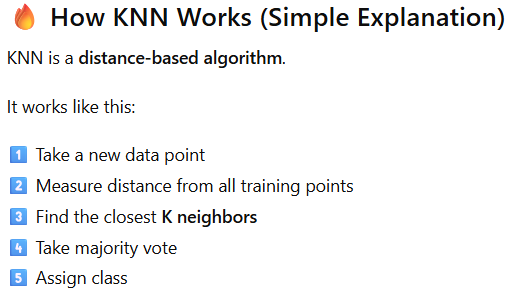

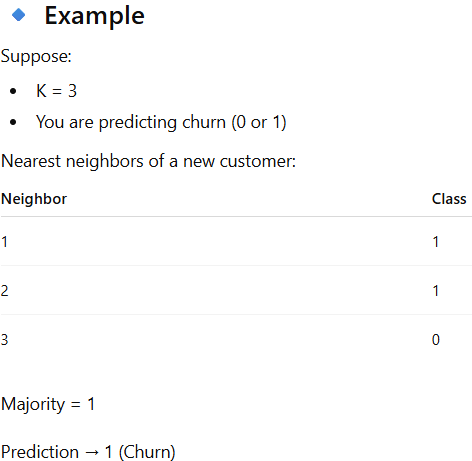

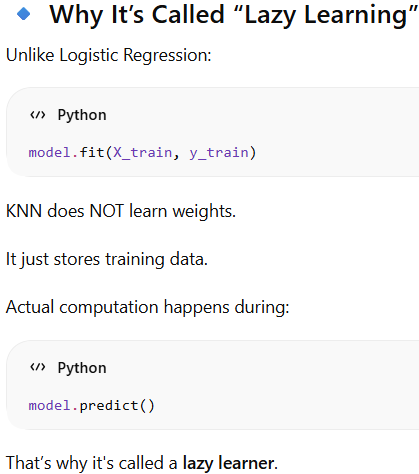

In [114]:
# Next, we going to keep grid search cross validation
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv = 5)
# Set the cross validation to 5 which basically splits our data into 5 folds
# This line only creates the object. Training happens only after: gridkn.fit(X_train, y_train)
# param_grid = {'', '', ''} --> GridSearch will try ALL combinations
# This means 5-fold cross-validation. Training data is split into 5 parts:
          # Train on 4 parts, Validate on 1 part, Repeat 5 times, Take average accuracy

# Create a GridSearch object to automatically find the best hyperparameters for KNN using 5-fold cross-validation.

We creating a Grid Search object that will:
- 1️⃣ Try different hyperparameter combinations for KNN
- 2️⃣ Use 5-fold cross-validation
- 3️⃣ Find the best parameter set

In [73]:
# Now we going to train it with using the fit method on X train and Y train
gridkn.fit(X_train, y_train) # Train the GridSearch model
# Trains multiple KNN models using different parameter combinations and 5-fold cross-validation

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [74]:
# We have this model ready, now lets check with the best parameters
gridkn.best_params_ # Get the best hyperparameters
# Returns the best hyperparameter combination found during tuning

{'n_neighbors': 7, 'weights': 'uniform'}

In [75]:
gridkn.predict(X_test) # We can make the predictions like this right now
# Make predictions using the best model
# Uses the best KNN model to make predictions on test data

array([1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [76]:
y_pred = gridkn.predict(X_test)

**gridkn.predict(X_test):**
- 1️⃣ Takes the best KNN model found during GridSearch
- 2️⃣ Uses it to predict the class for each row in X_test
- 3️⃣ Returns predicted labels

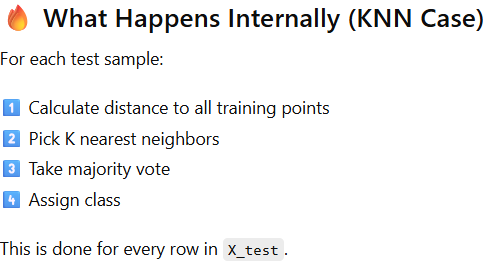

In [77]:
modelperformance(y_pred)

Accuracy score on model is 0.895


In [78]:
# Here our accuracy score decrease to 0.91
# So logistic regression performed better than the K neighbors classifier
# Next we going to check with support vector machine (SVM) model

In [79]:
from sklearn.svm import SVC
# Support Vector Classifier --> It is the classification version of Support Vector Machine (SVM)

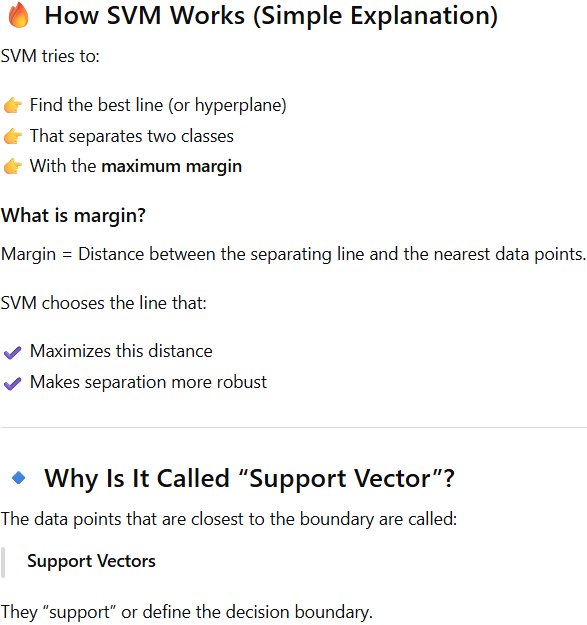

In [80]:
# Again we perform hyperparameter tuning to get the best performance as possible
# Now we going to initialize the base model
svm = SVC()

In [81]:
# Define the parameter grid
param_grid = {
    "C" : [0.01, 0.1, 0.5, 1],
    "kernel" : ["linear", "rbf", "poly"]     
}

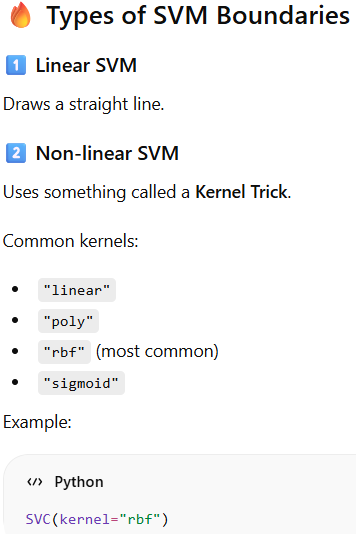

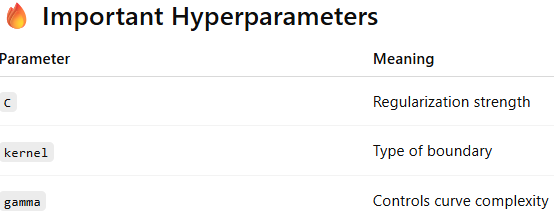

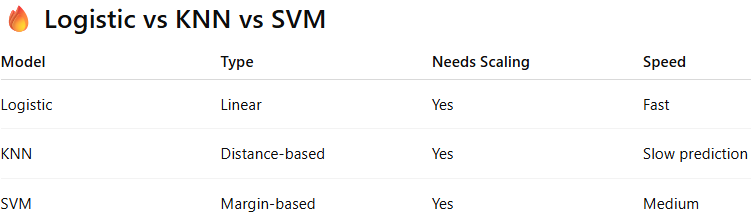

In [115]:
gridsvc = GridSearchCV(svm, param_grid, cv = 5)

In [83]:
gridsvc.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [84]:
gridsvc.best_params_
# This returns 👉 The best hyperparameter combination found during GridSearch.
# 👉 Returns the best hyperparameter values found by GridSearchCV for your SVM model.

{'C': 0.01, 'kernel': 'linear'}

In [85]:
# These are the best parameters for this SVM model with our dataset

In [86]:
y_pred = gridsvc.predict(X_test)

- 1️⃣ Uses the best SVM model found by GridSearch
- 2️⃣ Takes your test features (X_test)
- 3️⃣ Predicts the class for each test sample
- 4️⃣ Returns predicted labels

In [87]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [88]:
# Now lets call the model performance with this y_prediction
modelperformance(y_pred)

Accuracy score on model is 0.895


In [89]:
# So the accuracy score is 0.91 so this is leader by far
# Both logistic regression and SVM models are great so far and got better accuracy score 
# Next going to start the decision tree classifier

In [90]:
from sklearn.tree import DecisionTreeClassifier

In [91]:
param_grid = {
    "criterion" : ["gini", "entropy"],
    # This decides how the tree measures impurity. 
              #"gini" → Gini Impurity (default, faster) & "entropy" → Information Gain (based on log)
              # Both measure how mixed the classes are at a node. 👉 Lower impurity = better split.
    "splitter" : ["best", "random"],
    # "best" → Choose best possible split
    # "random" → Choose random split among best candidates
             # best usually performs better.
    "max_depth" : [None, 10, 20, 30],
    # Controls how deep the tree can grow. None → Grow until pure (can overfit 🚨) & 10, 20, 30 → Limit tree depth
    # Smaller depth → less overfitting & Larger depth → more complex model
    "min_samples_split" : [2, 5, 10],
    # Minimum samples required to split a node. 2 → Default & Larger value → Tree becomes more conservative
              # Higher value → reduces overfitting.
    "min_samples_leaf" : [1, 2, 4] # Minimum samples required at a leaf node.
}
# This try all combinations of these hyperparameter values and find the best one
# 👉 This dictionary defines all the hyperparameter values GridSearch will try to find the best Decision Tree model.

In [92]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)

**This line creates a GridSearch object that will:**
- 1️⃣ Try different combinations of Decision Tree hyperparameters
- 2️⃣ Use 5-fold cross-validation
- 3️⃣ Find the best-performing combination

At this stage, it has NOT trained yet.

Training happens only when you run: grid_tree.fit(X_train, y_train)

In [93]:
grid_tree.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [94]:
grid_tree.best_params_ # Lets find the best parameter

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 5,
 'splitter': 'random'}

In [95]:
y_pred = grid_tree.predict(X_test)

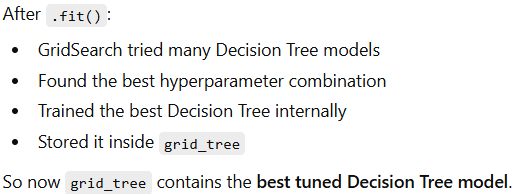

**grid_tree.predict(X_test):**
- 1️⃣ Takes the best Decision Tree model
- 2️⃣ Uses it to predict labels for X_test
- 3️⃣ Returns predicted class values

In [96]:
y_pred

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [97]:
modelperformance(y_pred)

Accuracy score on model is 0.86


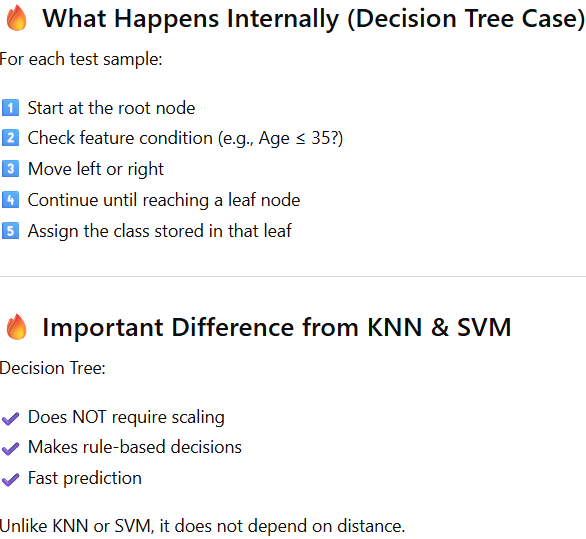

In [98]:
# This accuracy is lower than SVM and we are not going to this model
# Lastly at the modeling side, try with the RandomForeset

In [99]:
from sklearn.ensemble import RandomForestClassifier
# This imports the Random Forest classifier
# Random Forest is 👉 An ensemble method 👉 Made of many Decision Trees 👉 Combines their outputs
# Instead of using one tree (like DecisionTreeClassifier), it uses multiple trees and takes majority vote.

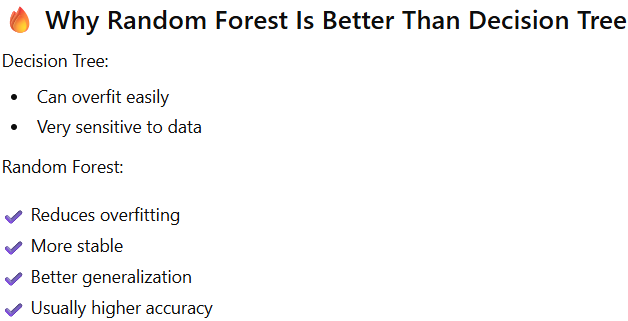

In [100]:
rfc_model = RandomForestClassifier() # Just initializing the algorithm

In [101]:
param_grid = {
    "n_estimators" : [32, 64, 128, 256],
    "max_features" : [2, 3, 4],
    "bootstrap" : [True, False]
}

In [102]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv = 5)
# This creates a GridSearch object for tuning Random Forest
# It means 👉 Try different hyperparameter combinations 👉 Use 5-fold cross-validation 👉 Find the best Random Forest configuration

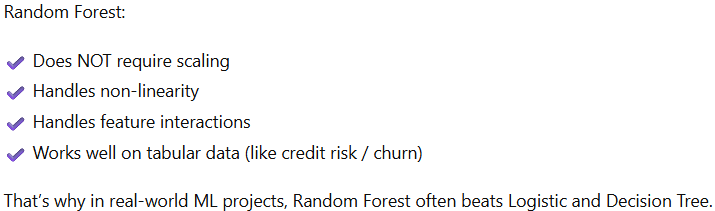

👉 Import Random Forest, create a model, and set up GridSearchCV to automatically find the best hyperparameters using 5-fold cross-validation.

In [103]:
grid_rfc

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [104]:
grid_rfc.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,64


In [105]:
# Lets see the best parameters
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64}

In [106]:
y_pred = grid_rfc.predict(X_test)

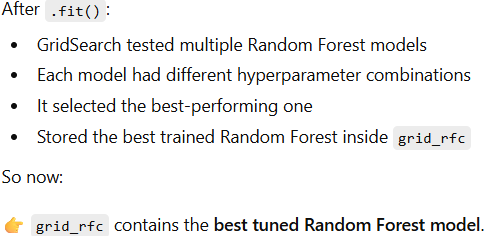

**grid_rfc.predict(X_test):**
- 1️⃣ Takes the best Random Forest model
- 2️⃣ Passes test features (X_test) into it
- 3️⃣ Each tree makes a prediction
- 4️⃣ The forest takes majority vote
- 5️⃣ Returns final predicted class

In [107]:
modelperformance(y_pred)

Accuracy score on model is 0.85


In [108]:
# So the best performing model is SVM
# So the grid svc is the best parameter

In [109]:
# Lets call that grid svc
gridsvc # gridsvc is 👉 A GridSearchCV object 👉 That contains many trained SVM models 👉 And stores the best one
# gridsvc is a GridSearchCV object that stores multiple trained SVM models and the best one among them

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [110]:
# Along with gridsvc, pack the best estimator
best_model = gridsvc.best_estimator_
# This returns 👉 The actual trained model object 👉 With the best hyperparameters 👉 Already fitted on the full training data
# Extract the best trained SVM model found by GridSearch and store it for direct use

In [111]:
best_model

,C,0.01
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [112]:
# Export this best model to joblib
joblib.dump(best_model, "model.pkl")
# 👉 Saving only the best model for deployment 👉 Or building a clean ML pipeline using Pipeline + GridSearch

['model.pkl']